# 📊 Multiple Linear Regression

## 🧠 Why Move Beyond Simple Linear Regression?

In reality, we rarely predict an outcome based on just **one variable**. If we want to predict product sales, looking solely at TV advertising ignores the impact of Radio and Newspaper budgets.

### 🦈 The Shark Attack Example
> If you run a simple regression comparing "Shark Attacks" (Response) to "Ice Cream Sales" (Predictor) at a beach, you will find a strong positive relationship. Does ice cream cause shark attacks? **No.** Both are driven by a third variable: **higher temperatures/Summer**. Multiple regression allows us to "control" for this hidden variable, instantly breaking the false relationship!

### 🚫 Why NOT Fit Separate Simple Regressions?

| Problem | Explanation |
|---------|-------------|
| **How to combine?** | Three separate models → Three different predictions. Which one to use? |
| **Ignoring other variables** | Each model ignores the other predictors, leading to misleading estimates if predictors are correlated |

## 🎯 The 4 Key Questions We Must Answer:

1. **Is there a relationship?** Is at least one predictor useful?
2. **Which predictors matter?** Do all predictors help, or just a subset?
3. **How well does the model fit?** What is the accuracy of the model?
4. **How accurate are our predictions?** What is the uncertainty of a specific prediction?

## 📋 Learning Objectives

✅ Understand Multiple Linear Regression (MLR)  
✅ Interpret regression coefficients correctly ("holding other variables fixed")  
✅ Understand the F-statistic for overall significance  
✅ Master Variable Selection (Forward, Backward, Mixed)  
✅ Evaluate model fit using RSE and R²  
✅ Differentiate Confidence vs Prediction Intervals  
✅ Understand confounding, surrogate variables, and overfitting  

## 📐 1. The Multiple Linear Regression Equation

The model assumes that the relationship between $Y$ and $p$ predictors is linear:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p + \epsilon$$

### 🔍 Detailed Term Breakdown

| Symbol | Name | Simple Meaning | Example (Advertising) |
|--------|------|----------------|------------------------|
| **$Y$** | Response/Dependent Variable | What we predict | Sales (units) |
| **$X_j$** | Predictor/Independent Variable | What we use to predict | TV, Radio, Newspaper budgets |
| **$\beta_0$** | Intercept | Expected Y when ALL X = 0 | Base sales with no advertising |
| **$\beta_j$** | Slope/Coefficient | Average change in Y per unit increase in $X_j$, **holding all other Xs fixed** | TV: +0.046 units per $1k spent |
| **$\epsilon$** | Error Term | Everything NOT captured by our model | Weather, competition, economy |

### 🎩 The Prediction Equation (After Training)
$$\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x_1 + \hat{\beta}_2 x_2 + \dots + \hat{\beta}_p x_p$$

*(The "hat" symbol $\hat{}$ denotes values estimated from sample data)*

### 🔑 THE MOST IMPORTANT IDEA: "Holding All Other Variables Fixed"
This phrase is the superpower of Multiple Regression. This is the most crucial concept in Multiple Regression. 
*   **Layman Analogy:** Imagine trying to figure out if drinking coffee causes weight gain. If you just look at coffee drinkers, you might notice they weigh more. But what if coffee drinkers also tend to eat more donuts? The donuts are the confounder! 
*   Multiple regression mathematically "holds donut consumption fixed" (pretends everyone eats the exact same number of donuts) so it can isolate the *true, independent* effect of coffee. 


> When we say $\beta_{TV} = 0.046$: "For every additional $1,000 spent on TV advertising, sales increase by 0.046 units, WHILE Radio and Newspaper spending remain CONSTANT." This allows us to isolate the **pure effect** of each variable!

In [10]:
# ============================================
# 📊 SETUP: Import Libraries & Load Data
# ============================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the Advertising dataset
df = pd.read_csv(r"D:\Projects\ISLP_withApplicationsInPython\data\Advertising.csv", index_col=0)

# Define predictors (X) and response (y)
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']

print("📊 Dataset Overview:")
print(f"   Observations: {len(df)}")
print(f"   Columns: {list(df.columns)}")
print("\n📋 First 5 rows:")
display(df.head())
print("\n📈 Statistical Summary:")
display(df.describe())



📊 Dataset Overview:
   Observations: 200
   Columns: ['TV', 'radio', 'newspaper', 'sales']

📋 First 5 rows:


,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9



📈 Statistical Summary:


,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


## 🕵️‍♂️ 2. The Illusion of Simple Regression: Surrogate Variables

### The Puzzling Case of Newspaper Advertising

| Model | Newspaper Coefficient | Newspaper p-value | Conclusion |
|-------|----------------------|-------------------|------------|
| **Simple Regression** (Newspaper only) | ~0.055 | < 0.001 | ✅ Significant! |
| **Multiple Regression** (TV + Radio + Newspaper) | ~-0.001 | 0.86 | ❌ NOT Significant! |

### 🤔 Why the Dramatic Difference?

Look at the correlation between Radio and Newspaper: **~0.35**. Markets that spend heavily on Radio **also** tend to spend heavily on Newspaper.

- In **Simple Regression**: Newspaper acts as a **SURROGATE** for Radio. It gets "credit" for the sales boost actually caused by Radio.
- In **Multiple Regression**: Radio is already in the model, so it "steals back" its explanatory power. Newspaper is revealed to have **zero unique contribution**.

### 🦈 Classic Confounding Example
```
Ice Cream Sales ↑ → Shark Attacks ↑   (CORRELATION exists!)
                                       
Hidden Variable: TEMPERATURE ↑        
  → More people at beaches             
  → More ice cream sales               
  → More shark attacks                 
                                       
Ice Cream does NOT cause Shark Attacks!
```

> **Correlation ≠ Causation** — One of the most important principles in Data Science!


📊 CORRELATION MATRIX
              TV  radio  newspaper  sales
TV         1.000  0.055      0.057  0.782
radio      0.055  1.000      0.354  0.576
newspaper  0.057  0.354      1.000  0.228
sales      0.782  0.576      0.228  1.000


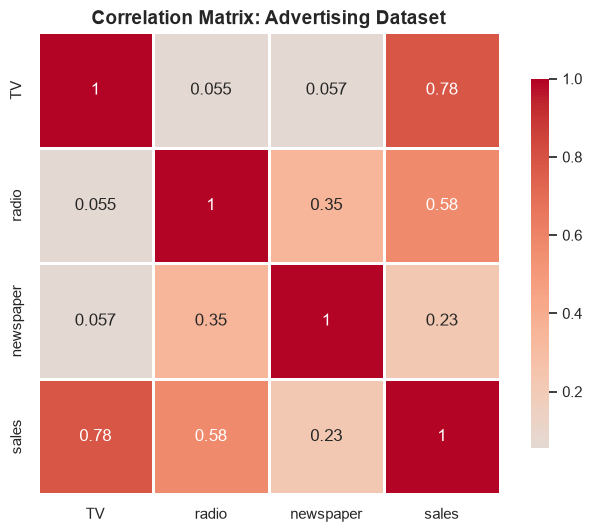


📰 SIMPLE REGRESSION: Sales ~ Newspaper
   Coefficient: 0.0547
   p-value:     0.001148
   R²:          0.0521

📊 MULTIPLE REGRESSION: Sales ~ TV + Radio + Newspaper
   Newspaper Coefficient: -0.0010
   Newspaper p-value:     0.859915
   R²:                    0.8972

💡 CONCLUSION: Newspaper is NOT significant in Multiple Regression!
   Radio was the true driver; Newspaper was just a surrogate.


In [4]:
# ============================================
# 🕵️‍♂️ SIMPLE vs MULTIPLE REGRESSION COMPARISON
# ============================================

# 1. Correlation Matrix
print("=" * 60)
print("📊 CORRELATION MATRIX")
print("=" * 60)
corr_matrix = df[['TV', 'radio', 'newspaper', 'sales']].corr().round(3)
print(corr_matrix)

# Visualize correlation
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Advertising Dataset', fontsize=14, fontweight='bold')
plt.show()

# 2. Simple Linear Regression for Newspaper
X_news_const = sm.add_constant(df['newspaper'])
model_simple_news = sm.OLS(y, X_news_const).fit()

print("\n" + "=" * 60)
print("📰 SIMPLE REGRESSION: Sales ~ Newspaper")
print("=" * 60)
print(f"   Coefficient: {model_simple_news.params['newspaper']:.4f}")
print(f"   p-value:     {model_simple_news.pvalues['newspaper']:.6f}")
print(f"   R²:          {model_simple_news.rsquared:.4f}")

# 3. Multiple Linear Regression (All Media)
X_all_const = sm.add_constant(X)
model_full = sm.OLS(y, X_all_const).fit()

print("\n" + "=" * 60)
print("📊 MULTIPLE REGRESSION: Sales ~ TV + Radio + Newspaper")
print("=" * 60)
print(f"   Newspaper Coefficient: {model_full.params['newspaper']:.4f}")
print(f"   Newspaper p-value:     {model_full.pvalues['newspaper']:.6f}")
print(f"   R²:                    {model_full.rsquared:.4f}")

print("\n💡 CONCLUSION: Newspaper is NOT significant in Multiple Regression!")
print("   Radio was the true driver; Newspaper was just a surrogate.")

## 🧪 3. Question 1: Is At Least One Predictor Useful? (The F-Test)

In simple regression, we used a **t-test** to check if $\beta_1 = 0$. In multiple regression, we must test if **ALL** $p$ coefficients are simultaneously zero.

### Hypotheses
| Hypothesis | Meaning | Mathematical Form |
|------------|---------|-------------------|
| **Null ($H_0$)** | No predictor matters | $\beta_1 = \beta_2 = \dots = \beta_p = 0$ |
| **Alternative ($H_a$)** | At least one predictor matters | At least one $\beta_j \neq 0$ |

### 🎲 The Multiple Testing Problem (Why we can't just use t-tests)
If you have 100 useless predictors and you test each one individually at a 5% significance level, you are basically rolling a 20-sided die 100 times. Statistically, you will roll a "1" (a false positive) about 5 times purely by luck! If you just look at individual p-values, you'll be tricked into thinking 5 variables are important. The F-statistic is the ultimate lie-detector test that checks all variables *simultaneously*.

### The F-Statistic Formula

When we build a Multiple Linear Regression model, we need to answer: **"Is our model actually useful, or could random noise explain the data just as well?"** The **F-statistic** answers this question.

$$F = \frac{(TSS - RSS) / p}{RSS / (n - p - 1)}$$

### 🔍 Deep Dive into the Formula Terms:

| Term | Full Name | Formula | Meaning |
|------|-----------|---------|---------|
| **TSS** | Total Sum of Squares | $\sum(y_i - \bar{y})^2$ | Total variance in Y before any model |
| **RSS** | Residual Sum of Squares | $\sum(y_i - \hat{y}_i)^2$ | Variance NOT explained by the model |
| **TSS - RSS** | Explained Variance | — | Variance successfully explained |
| **p** | Number of predictors | — | Divides numerator for "average per predictor" |
| **n-p-1** | Degrees of Freedom | — | Adjusts for parameters estimated |

### 🧠 Intuitive Interpretation
$$F = \frac{\text{Explained Variance (per predictor)}}{\text{Unexplained Variance (per df)}}$$

-   **Numerator $(TSS - RSS)/p$**: The *average* variance explained per predictor.
-   **Denominator $RSS/(n - p - 1)$**: The *average* variance unexplained per degree of freedom (this is exactly $RSE^2$!).
-   **Intuition**: The F-statistic is simply the ratio of **Explained Variance** to **Unexplained Variance**. 
- **If $H_0$ is true** (no relationship): Both numerator and denominator estimate $\sigma^2$ → **$F \approx 1$**
- *   If $H_0$ is true, both numerator and denominator estimate the same error variance $\sigma^2$, so **$F \approx 1$**. If there is a relationship, the numerator gets huge, making **$F > 1$**. 
> **If $H_a$ is true** (relationship exists): Numerator > $\sigma^2$ → **$F > 1$**
- **Large F → Tiny p-value → Reject $H_0$**

### Why NOT Just Check Individual p-values? (The Multiple Testing Problem)
> If you have **100 predictors** and NONE actually matter, by pure random chance ~5 of them will show p < 0.05! The F-statistic tests all predictors simultaneously, protecting you from this **false discovery** trap.

### 🧩 Deep Dive 1: Why do TSS and RSS appear?

To understand the F-statistic, we first need to understand the "accounting of variance." Think of the total variability in your data as a budget that must be spent.

#### 1. TSS (Total Sum of Squares): The "Baseline Ignorance"
$$ SS = \sum_{i=1}^n (y_i - \bar{y})^2 $$
*   **What it is:** The total variance in the response $Y$ *before* we build any model.
*   **Intuition:** If you knew absolutely nothing about your predictors ($X$), your best guess for $Y$ would simply be the average ($\bar{y}$). TSS measures the total squared error you would make by always guessing the mean. It is your **baseline ignorance**.
* **TSS represents the "worst-case" error** — the total squared error if we used ONLY the mean to predict everything. It's the benchmark against which any model must compete.

#### 2. RSS (Residual Sum of Squares): The "Leftover Ignorance"
After fitting our regression model, we now have predictions for each observation:
$$ RSS = \sum_{i=1}^n (y_i - \hat{y}_i)^2 $$
*   **What it is:** The variance in $Y$ that is *left unexplained* after you fit your regression model.
*   **Intuition:** Even after drawing the best possible regression plane, you still make mistakes. RSS is the sum of those squared mistakes. It is your **leftover ignorance**. A perfect model would have RSS = 0 (all points exactly on the regression line). A useless model would have RSS ≈ TSS (explained nothing!).

#### 3. The relationship between TSS and RSS (,i.e., TSS - RSS: The "Knowledge Gained")
$$ \text{Explained Variance} = TSS - RSS $$
- TSS = Total variation BEFORE modeling
-  RSS = Variation AFTER modeling (leftovers)
-  TSS - RSS = Variation EXPLAINED by the model
>  **Intuition:** If Baseline Ignorance (TSS) minus Leftover Ignorance (RSS) equals the Knowledge Gained, then this term represents exactly how much variance your model successfully **explained** using the predictors.

```
Total Variation (TSS)

|---------------------------------------|

Explained Variation (ESS)

|------------------------------|

Unexplained Variation (RSS)

|----------|
```
## 📉 Deep Dive 2: Why are the degrees of freedom $n - p - 1$?

When we calculate the Residual Standard Error ($RSE$), we divide by $n - p - 1$ instead of $n$. Why?

### **Degrees of Freedom (df)**

The number of **independent pieces of information** available to estimate variability after accounting for constraints.
### 🔗 Analogy: Counting Free Choices

```
Imagine you have 5 numbers that MUST sum to 100:

Number 1: ___ (free choice)
Number 2: ___ (free choice)  
Number 3: ___ (free choice)
Number 4: ___ (free choice)
Number 5: ___ (NOT free — must make the sum 100!)

→ 5 numbers, 1 constraint → 4 degrees of freedom
```

### 🧮 Applying to Regression

| Step | What We Do | Degrees of Freedom Used |
|------|------------|------------------------|
| **Start** | n raw observations | **n** |
| **Estimate β₀** | Fit the intercept (1 parameter) | Lose 1 df |
| **Estimate β₁, β₂, ..., βₚ** | Fit p slope parameters | Lose p df |
| **Remaining** | Independent pieces left | **n − p − 1** |

### 📊 Why n − p − 1 Matters

When calculating the variance of residuals (RSE²), we need to divide by the **correct** degrees of freedom:

$$RSE^2 = \frac{RSS}{n - p - 1}$$

**Why not divide by n?** That would **underestimate** the true error variance (biased estimator). We "spent" p+1 degrees of freedom estimating parameters, so we have fewer independent pieces left to estimate variance.


## 🧪 Deep Dive 3: The Magic of the F-Statistic

The F-statistic is the ultimate lie-detector test for your model. Let's look at its formula again:

$$ F = \frac{(TSS - RSS) / p}{RSS / (n - p - 1)} $$

### Breaking down the Ratio:
*   **Numerator:** $\frac{TSS - RSS}{p}$ = The *average* variance explained **per predictor**.
*   **Denominator:** $\frac{RSS}{n - p - 1}$ = The *average* variance unexplained **per degree of freedom**. (Notice that this denominator is exactly $RSE^2$, our best estimate of the true error variance $\sigma^2$).

### 🧠 The Intuition under $H_0$ (The Null Hypothesis):
$H_0$ states that **none** of the predictors are useful ($\beta_1 = \dots = \beta_p = 0$). 
If the predictors are completely useless, they are just random noise. 
*   The "variance explained" by these useless predictors is actually just random noise masquerading as a signal. Therefore, the Numerator is just estimating the true error variance: **Numerator $\approx \sigma^2$**.
*   The Denominator is *also* estimating the true error variance: **Denominator $\approx \sigma^2$**.

Therefore, the ratio is:
$$ F \approx \frac{\sigma^2}{\sigma^2} = 1 $$

### 🚀 What if $H_a$ is true?
If the predictors *are* useful, they explain **real signal** on top of the random noise. 
*   The Numerator becomes: $\sigma^2 + \text{Signal}$.
*   The Denominator remains: $\sigma^2$.
*   The ratio becomes: $F = \frac{\sigma^2 + \text{Signal}}{\sigma^2} > 1$.

**Conclusion:** An F-statistic near 1 means your model is no better than random guessing. An F-statistic much greater than 1 means your model has found a real signal!

## 🧪 Deep Dive 3: The Magic of the F-Statistic

The F-statistic is the ultimate lie-detector test for your model. Let's look at its formula again:

$$ F = \frac{(TSS - RSS) / p}{RSS / (n - p - 1)} $$

### Breaking down the Ratio:
*   **Numerator:** $\frac{TSS - RSS}{p}$ = The *average* variance explained **per predictor**.
*   **Denominator:** $\frac{RSS}{n - p - 1}$ = The *average* variance unexplained **per degree of freedom**. (Notice that this denominator is exactly $RSE^2$, our best estimate of the true error variance $\sigma^2$).

### 🧠 The Intuition under $H_0$ (The Null Hypothesis):
$H_0$ states that **none** of the predictors are useful ($\beta_1 = \dots = \beta_p = 0$). 
If the predictors are completely useless, they are just random noise. 
*   The "variance explained" by these useless predictors is actually just random noise masquerading as a signal. Therefore, the Numerator is just estimating the true error variance: **Numerator $\approx \sigma^2$**.
*   The Denominator is *also* estimating the true error variance: **Denominator $\approx \sigma^2$**.

Therefore, the ratio is:
$$ F \approx \frac{\sigma^2}{\sigma^2} = 1 $$

### 🚀 What if $H_a$ is true?
If the predictors *are* useful, they explain **real signal** on top of the random noise. 
*   The Numerator becomes: $\sigma^2 + \text{Signal}$.
*   The Denominator remains: $\sigma^2$.
*   The ratio becomes: $F = \frac{\sigma^2 + \text{Signal}}{\sigma^2} > 1$.

**Conclusion:** An F-statistic near 1 means your model is no better than random guessing. An F-statistic much greater than 1 means your model has found a real signal!

| Component | Why It's There | What It Measures |
|-----------|---------------|------------------|
| **TSS** | $\sum(y_i - \bar{y})^2$ | Total information in Y (benchmark) |
| **RSS** | $\sum(y_i - \hat{y}_i)^2$ | Information NOT captured by model |
| **TSS − RSS** | Model's contribution | Information successfully explained |
| **÷ p** | Normalize by predictor count | Average explained per predictor |
| **÷ (n−p−1)** | Correct degrees of freedom | Unbiased noise estimate |
| **Why F ≈ 1 under H₀?** | Both numerator and denominator estimate the same thing! | NA | 
| **Geometric meaning?** | Projections, right triangles, and Pythagoras in n-dimensional space | NA |


### 🔑 The One-Sentence Summary

> **The F-statistic is a signal-to-noise ratio: it compares how much variation your model explains (per predictor) to how much random noise remains (per degree of freedom). When there's no real relationship, both measure the same noise level → F ≈ 1.**

In [12]:
# ============================================
# 🧪 F-STATISTIC DEMONSTRATION
# ============================================

print("=" * 60)
print("🧪 F-TEST RESULTS")
print("=" * 60)

print(f"   F-statistic: {model_full.fvalue:.2f}")
print(f"   p-value:     {model_full.f_pvalue:.6e}")
print(f"   Degrees of Freedom: ({int(model_full.df_model)}, {int(model_full.df_resid)})")

print("\n🔍 Interpretation:")

if model_full.f_pvalue < 0.001:
    print("   ✅ OVERWHELMING evidence against H₀")
    print(f"   p = {model_full.f_pvalue:.2e} means: If ALL predictors were truly useless,")
    print("   we'd see an F-statistic this extreme essentially NEVER by chance!")
    print("   → We REJECT H₀: At least one advertising medium affects sales!")

# ============================================
# 🔬 MULTIPLE TESTING PROBLEM DEMONSTRATION
# ============================================

print("\n" + "=" * 60)
print("🔬 MULTIPLE TESTING PROBLEM DEMONSTRATION")
print("=" * 60)

np.random.seed(42)

n = 100
p = 100

X_random = np.random.normal(0, 1, (n, p))
y_random = np.random.normal(0, 1, n)

false_positives = 0

for j in range(p):

    X_single = sm.add_constant(X_random[:, j])

    model_single = sm.OLS(
        y_random,
        X_single
    ).fit()

    # p-value of predictor (index 1)
    if model_single.pvalues[1] < 0.05:
        false_positives += 1

print(f"   Predictors: {p} (ALL truly unrelated to Y)")
print(f"   False positives at α=0.05: {false_positives}")
print(f"   Expected by chance: ~{p * 0.05:.0f}")
print(f"   ⚠️ Individual t-tests would falsely declare {false_positives} 'significant' variables!")

🧪 F-TEST RESULTS
   F-statistic: 570.27
   p-value:     1.575227e-96
   Degrees of Freedom: (3, 196)

🔍 Interpretation:
   ✅ OVERWHELMING evidence against H₀
   p = 1.58e-96 means: If ALL predictors were truly useless,
   we'd see an F-statistic this extreme essentially NEVER by chance!
   → We REJECT H₀: At least one advertising medium affects sales!

🔬 MULTIPLE TESTING PROBLEM DEMONSTRATION
   Predictors: 100 (ALL truly unrelated to Y)
   False positives at α=0.05: 4
   Expected by chance: ~5
   ⚠️ Individual t-tests would falsely declare 4 'significant' variables!


## 🎯 4. Question 2: Which Predictors Actually Matter? (Variable Selection)

Once we know *some* predictors are useful, we want to know *which ones*. This is called **Variable Selection**. 

### The Combinatorial Explosion Problem

The curse of $2^p$, if we have $p$ predictors, there are $2^p$ possible models (each predictor can be either "in" or "out"). If $p=30$, there are over **1 billion** possible models! Trying them all is computationally impossible.

| Predictors (p) | Possible Models ($2^p$) |
|----------------|--------------------------|
| 5 | 32 |
| 10 | 1,024 |
| 20 | 1,048,576 |
| 30 | **1,073,741,824** (over 1 billion!) |

> Trying ALL combinations becomes impossible → We need **automated approaches**!


### 🗺️ The 3 Classical Automated Approaches

```mermaid
graph TD

    A["Variable Selection"]

    A --> B["Forward Selection"]
    A --> C["Backward Selection"]
    A --> D["Mixed Selection"]

    B --> B1["Null Model<br/>Start with Null Model<br/>(0 variables)"]
    B1 --> B2["Add Best Predictor<br/>Add variable that lowers RSS the most"]
    B2 --> B3["Repeat until stopping rule is met"]

    C --> C1["Full Model<br/>Start with Full Model<br/>(all variables)"]
    C1 --> C2["<br/>Remove variable with largest p-value<br/>i.e., Worst Predictor"]
    C2 --> C3["<br/>Repeat until all remaining variables are significant"]

    D --> D1["Start with Null Model"]
    D1 --> D2["Add best variable/predictor"]
    D2 --> D3["Remove if Needed<br/>Check existing variables"]
    D3 --> D4["Repeat<br/>Remove insignificant variables<br/>and add next best predictor"]
```


```
┌───────────────────────────────────────────────────────────────────────┐
│  1. FORWARD SELECTION                                                 │
│  Start: NULL MODEL (intercept only)                                   │
│  Step: Add the predictor that LOWERS RSS the most                     │
│  Repeat: Until no meaningful improvement                              │
│  ✅ Can work when p > n  |  ❌ "Greedy" — can't remove variables     │
├───────────────────────────────────────────────────────────────────────┤
│  2. BACKWARD SELECTION                                                │
│  Start: FULL MODEL (all predictors)                                   │
│  Step: Remove predictor with HIGHEST p-value                          │
│  Repeat: Until all remaining p-values < threshold                     │
│  ✅ Considers interactions  |  ❌ Requires n > p                     │
├───────────────────────────────────────────────────────────────────────┤
│  3. MIXED SELECTION (Stepwise)                                        │
│  Start: NULL MODEL                                                    │
│  Step: Add best predictor → Check if any existing become insignificant│
│  Repeat: Add/Remove iteratively until stable                          │
│  ✅ Most flexible  |  ❌ More complex to implement                   │
└───────────────────────────────────────────────────────────────────────┘
```

### 📏 Model Selection Criteria

| Criterion | Goal | Formula/Approach |
|-----------|------|------------------|
| **Adjusted R²** | Maximize (penalizes complexity) | $1 - \frac{RSS/(n-p-1)}{TSS/(n-1)}$ |
| **AIC** (Akaike Information Criterion) | Minimize | Balances fit + complexity |
| **BIC** (Bayesian Information Criterion) | Minimize | Penalizes complexity MORE than AIC |
| **Mallows' Cp** | Close to p | Measures if smaller model matches full model |
```



## 📊 5. Question 3: How Well Does the Model Fit?

We assess the fit using two main metrics. Notice how the formulas change from Simple to Multiple regression!

### 📏 Residual Standard Error (RSE)

$$RSE = \sqrt{\frac{RSS}{n - p - 1}}$$

| Component | Meaning |
|-----------|---------|
| **RSS** | Sum of squared residuals (total error) |
| **n** | Number of observations |
| **p** | Number of predictors |
| **n-p-1** | Degrees of freedom (adjusts for complexity) |

**Interpretation**: The average amount that the response deviates from the true regression plane.


### 📊 The R² Statistic

$$R^2 = 1 - \frac{RSS}{TSS} = \frac{Explained\ Variance}{Total\ Variance}$$

- **$R^2 = 1$**: Perfect fit
- **$R^2 = 0.90$**: 90% of variance explained
- **$R^2 = 0$**: Model explains nothing

*   **Interpretation**: The proportion of variance in $Y$ explained by the model. 
 
### ⚠️ The R² Trap: Why R² ALWAYS Increases
$R^2$ will **always increase** when you add a new variable to the model, even if that variable is completely useless (like your Zodiac sign)! This happens because adding a variable always decreases $RSS$ on the training data. Relying solely on $R^2$ leads to **overfitting**—a model that memorizes the training data noise but fails in the real world.

> Adding ANY variable — even **random noise** — will always decrease RSS on training data, making R² go up. This encourages **OVERFITTING**!

| Model | R² | RSE | Verdict |
|-------|-----|-----|---------|
| TV only | 0.612 | 3.26 | Decent |
| TV + Radio | 0.897 | 1.69 | Much better! |
| TV + Radio + Newspaper | 0.897 | 1.69 | **NO improvement!** R² barely budged, RSE stayed same |

> **Conclusion:** Newspaper adds complexity without improving fit → Remove it!

In [6]:
# ============================================
# 📊 MODEL COMPARISON: R², RSE, Adjusted R²
# ============================================

def evaluate_model(X_df, y, model_name):
    """Fit and evaluate a regression model"""
    X_const = sm.add_constant(X_df)
    model = sm.OLS(y, X_const).fit()
    rse = np.sqrt(model.mse_resid)
    return {
        'Model': model_name,
        'R²': round(model.rsquared, 4),
        'Adj R²': round(model.rsquared_adj, 4),
        'RSE': round(rse, 4),
        'AIC': round(model.aic, 2),
        'BIC': round(model.bic, 2)
    }

# Compare different models
results = []
results.append(evaluate_model(df[['TV']], y, 'TV only'))
results.append(evaluate_model(df[['radio']], y, 'Radio only'))
results.append(evaluate_model(df[['newspaper']], y, 'Newspaper only'))
results.append(evaluate_model(df[['TV', 'radio']], y, 'TV + Radio'))
results.append(evaluate_model(df[['TV', 'radio', 'newspaper']], y, 'All Three'))

comparison_df = pd.DataFrame(results)
print("=" * 70)
print("📊 MODEL COMPARISON")
print("=" * 70)
print(comparison_df.to_string(index=False))

print("\n🔍 KEY INSIGHTS:")
print("   • TV + Radio is the BEST model (highest Adj R², lowest RSE)")
print("   • Adding Newspaper barely changes R² but keeps RSE same")
print("   • Newspaper should be REMOVED from the model!")

📊 MODEL COMPARISON
         Model     R²  Adj R²    RSE     AIC     BIC
       TV only 0.6119  0.6099 3.2587 1042.09 1048.69
    Radio only 0.3320  0.3287 4.2749 1150.67 1157.27
Newspaper only 0.0521  0.0473 5.0925 1220.67 1227.27
    TV + Radio 0.8972  0.8962 1.6814  778.39  788.29
     All Three 0.8972  0.8956 1.6855  780.36  793.56

🔍 KEY INSIGHTS:
   • TV + Radio is the BEST model (highest Adj R², lowest RSE)
   • Adding Newspaper barely changes R² but keeps RSE same
   • Newspaper should be REMOVED from the model!


## 🔮 6. Question 4: How Accurate Are Our Predictions?

When we predict $\hat{y}$ for a given set of $X$ values, there are **three sources of uncertainty**:

1. **Reducible Error**: The coefficients $\hat{\beta}$ are just estimates. The true population plane $f(X)$ is unknown. 
2. **Model Bias**: We assume the relationship is linear, but reality is rarely perfectly linear. 
3. **Irreducible Error**: Even if we knew the true $\beta$ values perfectly, individual data points will still vary randomly around the true plane due to $\epsilon$.


| Source | Type | Can We Reduce It? | Example |
|--------|------|-------------------|---------|
| **Coefficient Estimation** | Reducible | ✅ Yes (more data) | $\hat{\beta}$ varies sample-to-sample |
| **Model Bias** | Reducible | ✅ Yes (better model) | Assuming linear when true relationship is curved |
| **Random Error ($\epsilon$)** | Irreducible | ❌ No | Weather, human decisions, economic events |

### 📏 Confidence Interval vs Prediction Interval
*   **Confidence Interval (For Averages)**: "What will the *average* sales be across 1,000 cities with this ad budget?" 
    * *Analogy:* Predicting the average height of 1,000 people. You can be very precise because individual weirdness averages out. The interval is **narrow**.
*   **Prediction Interval (For Individuals)**: "What will the sales be in *one specific* city with this ad budget?" 
    * *Analogy:* Predicting the height of *one specific* person. They might be unusually tall or short. You need a much wider net to catch them. The interval is **wide** because it accounts for the irreducible error.

| Feature | Confidence Interval | Prediction Interval |
|---------|---------------------|---------------------|
| **What it predicts** | **AVERAGE** response for many observations | **SINGLE** specific observation |
| **Width** | Narrower | **MUCH Wider** |
| **Accounts for** | Reducible error only | Reducible + Irreducible error |
| **Example** | "Average sales across 1,000 cities with this budget" | "Sales in ONE specific city with this budget" |

### 📊 Advertising Example (TV=100, Radio=20)

| Interval Type | Lower Bound | Upper Bound |
|---------------|-------------|-------------|
| **95% Confidence** | 10,985 | 11,528 |
| **95% Prediction** | **7,930** | **14,580** |

> Notice the Prediction Interval is **much wider** — predicting individuals is harder than predicting averages!

In [14]:
# ============================================
# 🔮 CONFIDENCE vs PREDICTION INTERVALS
# ============================================

X_best = df[['TV', 'radio']]

X_best_const = sm.add_constant(
    X_best,
    has_constant='add'
)

model_best = sm.OLS(
    y,
    X_best_const
).fit()

# New observation
X_new = pd.DataFrame({
    'TV': [100],
    'radio': [20]
})

# Add intercept
X_new_const = sm.add_constant(
    X_new,
    has_constant='add'
)

# Ensure same column order as training
X_new_const = X_new_const[
    model_best.model.exog_names
]

# Prediction
pred = model_best.get_prediction(
    X_new_const
)

pred_df = pred.summary_frame(alpha=0.05)

print("=" * 70)
print("🔮 PREDICTION FOR: TV=$100k, Radio=$20k")
print("=" * 70)

print(
    f"Predicted Sales: "
    f"{pred_df['mean'].iloc[0]:.2f}"
)

print(
    f"95% Confidence Interval: "
    f"[{pred_df['mean_ci_lower'].iloc[0]:.2f}, "
    f"{pred_df['mean_ci_upper'].iloc[0]:.2f}]"
)

print(
    f"95% Prediction Interval: "
    f"[{pred_df['obs_ci_lower'].iloc[0]:.2f}, "
    f"{pred_df['obs_ci_upper'].iloc[0]:.2f}]"
)

🔮 PREDICTION FOR: TV=$100k, Radio=$20k
Predicted Sales: 11.26
95% Confidence Interval: [10.99, 11.53]
95% Prediction Interval: [7.93, 14.58]


## 🎤 Top Interview Questions

### 🟢 Basic Level
**Q1: What is Multiple Linear Regression?**
> **A:** An extension of Simple LR that uses MULTIPLE predictors to predict one response. Equation: $Y = \beta_0 + \beta_1X_1 + ... + \beta_pX_p + \epsilon$.

**Q2: What does "holding all other variables fixed" mean?**
> **A:** When interpreting a coefficient $\beta_j$, we assume ALL other predictors remain constant. This isolates the **pure effect** of that single variable.

### 🟡 Intermediate Level
**Q3: Why did Newspaper become insignificant in Multiple Regression when it was significant alone?**
> **A:** This is the **surrogate effect**. Newspaper was correlated with Radio. In simple regression, it got "credit" for Radio's effect. In multiple regression, Radio is already present, so Newspaper's true (zero) effect is revealed.

**Q4: What does the F-statistic test? Why not just check individual p-values?**
>**A:** Looking at individual p-values leads to the **multiple testing problem**. If you have 100 predictors and none of them are actually related to $Y$, by pure random chance, about 5 of them will have a p-value $< 0.05$. If you use individual p-values, you will likely falsely conclude that a relationship exists. The F-statistic tests all $p$ predictors *simultaneously* and adjusts for the number of predictors, maintaining the correct Type I error rate (e.g., 5%).

### 🔴 Advanced Level
**Q5: Why does R² always increase when adding variables? Why is this dangerous?**
> **A:** Adding variables always slightly reduces RSS on training data (more "knobs to turn"). This leads to **overfitting** — the model memorizes noise instead of learning patterns. Use Adjusted R², AIC, or BIC instead!

**Q6: Explain the difference between Confidence and Prediction Intervals.**
> **A:** Confidence Interval predicts the **AVERAGE** response (narrower, only reducible error). Prediction Interval predicts a **SINGLE** observation (much wider, includes irreducible error).
*   **Confidence Interval** is for *averages*. If we run 1,000 different cities with the exact same ad budget, the Confidence Interval tells us where the *average* sales of those 1,000 cities will fall. It is relatively narrow.
*   **Prediction Interval** is for *individuals*. If we pick just *one* specific city with that ad budget, the Prediction Interval tells us where that single city's sales will fall. It is much wider because individual cities have their own unique, unpredictable quirks (the irreducible error).
---

## 🧠 Fun Facts

1. 🦈 **Ice Cream & Sharks**: Simple regression shows a strong correlation between ice cream sales and shark attacks. Multiple regression reveals the confounder: **Summer/Temperature**. More people at beaches → more ice cream AND more shark attacks!

2. 🧮 **The Curse of $2^p$**: With 30 predictors, there are over **1 BILLION** possible model combinations. This exponential explosion is why automated selection methods exist!

3. 📊 **Origin of the F-statistic**: Named after **Ronald Fisher** (1920s), who developed it while analyzing agricultural crop yields at Rothamsted Experimental Station!

4. ⚖️ **The "Holding Fixed" Magic**: Multiple regression simulates a controlled experiment using purely observational data — isolating the exact marginal contribution of each variable!

5. 🏈 **NFL & Regression**: Modern NFL teams use multiple regression to predict draft success from combine metrics, showing how this 100-year-old method still drives million-dollar decisions!

## 🎯 Complete Chapter Summary

### The Multiple Linear Regression Equation
$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p + \epsilon$$

### Key Concepts Mastered:

| Concept | Key Point |
|---------|-----------|
| **Coefficient Interpretation** | "Holding all other predictors FIXED" |
| **F-Statistic** | Tests if ANY predictor is useful ($F \approx 1$ under $H_0$) |
| **Surrogate Variables** | Correlated predictors can "steal credit" in simple regression |
| **Forward Selection** | Start empty, add best predictor iteratively |
| **Backward Selection** | Start full, remove worst predictor iteratively |
| **Mixed Selection** | Combine forward + backward |
| **RSE** | Average prediction error $\sqrt{RSS/(n-p-1)}$ |
| **R² Trap** | R² always increases; use Adjusted R² instead |
| **Confidence Interval** | For AVERAGE response (narrower) |
| **Prediction Interval** | For SINGLE observation (wider) |
| **Reducible Error** | Can be reduced with better model/more data |
| **Irreducible Error** | Random noise that CANNOT be eliminated |

### 🚀 What's Next?
- **Polynomial Regression** (capturing non-linear relationships)
- **Regularization** (Ridge, Lasso, Elastic Net for when p > n)
- **Classification Models** (Logistic Regression)

> *Multiple Linear Regression is the foundation of modern Machine Learning. Master it, and you've built the base for everything else!* 🚀